<a href="https://colab.research.google.com/github/lusgaoliveira/imputacao-de-dados-e-previsao-com-redes-neurais/blob/main/imputacao-de-dados-e-previsao-com-redes-neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from metrics import mase, mape, smape, mpe, seasonal_mase

## 1. Importing the dataset and processing




In [29]:
# Carrega os dados
data = pd.read_csv("data/dados_dias.csv", sep=";", skiprows=9)

In [30]:
data.columns

Index(['Data Medicao', 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)',
       'PRESSAO ATMOSFERICA MEDIA DIARIA (AUT)(mB)',
       'TEMPERATURA DO PONTO DE ORVALHO MEDIA DIARIA (AUT)(°C)',
       'TEMPERATURA MAXIMA, DIARIA (AUT)(°C)',
       'TEMPERATURA MEDIA, DIARIA (AUT)(°C)',
       'TEMPERATURA MINIMA, DIARIA (AUT)(°C)',
       'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)',
       'UMIDADE RELATIVA DO AR, MINIMA DIARIA (AUT)(%)',
       'VENTO, RAJADA MAXIMA DIARIA (AUT)(m/s)',
       'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)', 'Unnamed: 11'],
      dtype='object')

In [31]:
data = data.drop(columns=['Unnamed: 11'], errors='ignore')

In [33]:
# Renomear as colunas
data.columns = [
    'data',
    'precipitacao_total_mm',
    'pressao_media_mb',
    'temperatura_ponto_orvalho_c',
    'temperatura_maxima_c',
    'temperatura_media_c',
    'temperatura_minima_c',
    'umidade_media_pct',
    'umidade_minima_pct',
    'vento_rajada_maxima_ms',
    'vento_velocidade_media_ms'
]


In [34]:
data.head()

,data,precipitacao_total_mm,pressao_media_mb,temperatura_ponto_orvalho_c,temperatura_maxima_c,temperatura_media_c,temperatura_minima_c,umidade_media_pct,umidade_minima_pct,vento_rajada_maxima_ms,vento_velocidade_media_ms
0,2009-06-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0,"8,9",NaN
1,2009-06-26,NaN,"986,7","18,2",29,"21,7",17,"80,4",50.0,"5,2","1,4"
2,2009-06-27,0,"988,4",19,28,"22,6","18,9","81,6",52.0,"7,6","1,7"
3,2009-06-28,0,"987,3","18,8",27,"21,9","19,2","83,5",55.0,"5,9","1,4"
4,2009-06-29,0,"985,3","18,4","28,5","22,3","18,6","80,8",48.0,"5,5","1,3"


In [62]:
data['data'] = pd.to_datetime(data['data'], errors='coerce')

data = data.set_index('data')

data = data.sort_index()

data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5669 entries, 2009-06-25 to 2024-12-31
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   precipitacao_total_mm        4531 non-null   float64
 1   pressao_media_mb             5098 non-null   float64
 2   temperatura_ponto_orvalho_c  5075 non-null   float64
 3   temperatura_maxima_c         5108 non-null   float64
 4   temperatura_media_c          5057 non-null   float64
 5   temperatura_minima_c         5109 non-null   float64
 6   umidade_media_pct            5137 non-null   float64
 7   umidade_minima_pct           5293 non-null   float64
 8   vento_rajada_maxima_ms       5203 non-null   float64
 9   vento_velocidade_media_ms    5007 non-null   float64
dtypes: float64(10)
memory usage: 487.2 KB


In [35]:
columns_to_convert = [
    'precipitacao_total_mm',
    'pressao_media_mb',
    'temperatura_ponto_orvalho_c',
    'temperatura_maxima_c',
    'temperatura_media_c',
    'temperatura_minima_c',
    'umidade_media_pct',
    'umidade_minima_pct',
    'vento_rajada_maxima_ms',
    'vento_velocidade_media_ms'
]

In [63]:
# A grande maioria dos valores das colunas está usando "vírgula" e não ".". Essa função cuida da conversão para o formato correto
def remove_comma(value):
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except ValueError:
            return value
    return value

In [64]:
for col in columns_to_convert:
    data[col] = data[col].map(remove_comma)

In [65]:
data.info()
print(data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5669 entries, 2009-06-25 to 2024-12-31
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   precipitacao_total_mm        4531 non-null   float64
 1   pressao_media_mb             5098 non-null   float64
 2   temperatura_ponto_orvalho_c  5075 non-null   float64
 3   temperatura_maxima_c         5108 non-null   float64
 4   temperatura_media_c          5057 non-null   float64
 5   temperatura_minima_c         5109 non-null   float64
 6   umidade_media_pct            5137 non-null   float64
 7   umidade_minima_pct           5293 non-null   float64
 8   vento_rajada_maxima_ms       5203 non-null   float64
 9   vento_velocidade_media_ms    5007 non-null   float64
dtypes: float64(10)
memory usage: 487.2 KB
precipitacao_total_mm          1138
pressao_media_mb                571
temperatura_ponto_orvalho_c     594
temperatura_maxima_c        

## 2. Statistics

In [66]:
# Usar o DataFrame original (já tratadas)
df_eda = data.copy()

# Estatísticas descritivas
print("Resumo estatístico:")
print(df_eda.describe())

Resumo estatístico:
       precipitacao_total_mm  pressao_media_mb  temperatura_ponto_orvalho_c  \
count            4531.000000       5098.000000                  5075.000000   
mean                2.273317        984.040624                    18.302010   
std                 7.606638          3.175418                     1.963249   
min                 0.000000        973.400000                     7.100000   
25%                 0.000000        981.800000                    17.000000   
50%                 0.000000        983.700000                    18.400000   
75%                 1.200000        986.300000                    19.700000   
max               123.400000        994.300000                    23.300000   

       temperatura_maxima_c  temperatura_media_c  temperatura_minima_c  \
count           5108.000000          5057.000000           5109.000000   
mean              30.864742            24.207139             19.677099   
std                3.291032             2.3596

### 2.1 Histogram

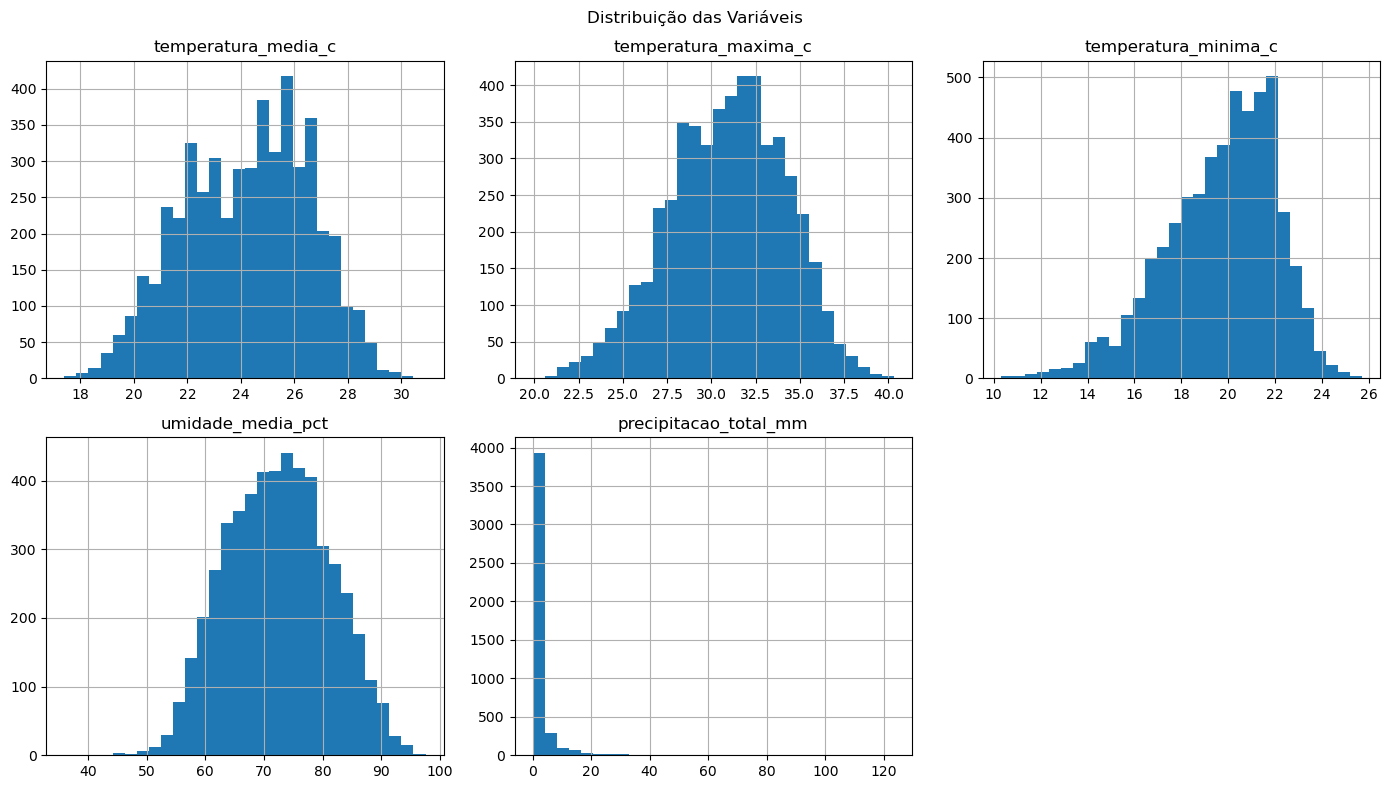

In [67]:
# Histograma das principais variáveis
variables_of_interest = [
    'temperatura_media_c',
    'temperatura_maxima_c',
    'temperatura_minima_c',
    'umidade_media_pct',
    'precipitacao_total_mm'
]


df_eda[variables_of_interest].hist(bins=30, figsize=(14, 8), layout=(2, 3))
plt.suptitle("Distribuição das Variáveis")
plt.tight_layout()
plt.show()

**Interpretação**:

### 2.2 Boxplots

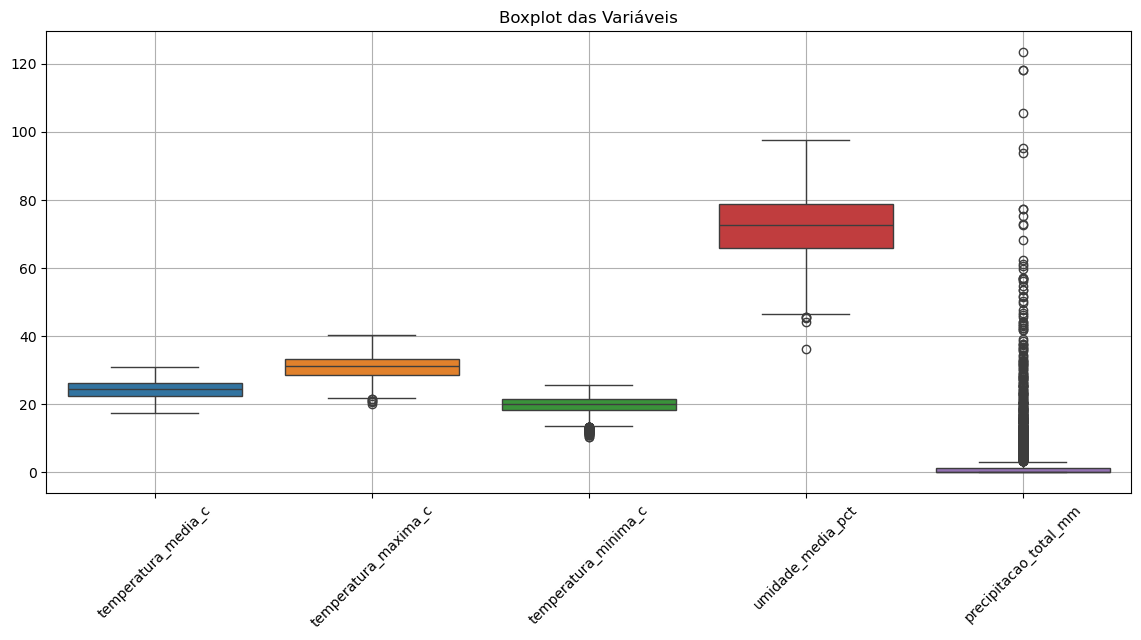

In [68]:
# Boxplots para detectar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_eda[variables_of_interest])
plt.title("Boxplot das Variáveis")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Interpretação:**

### 2.3 Heat Map

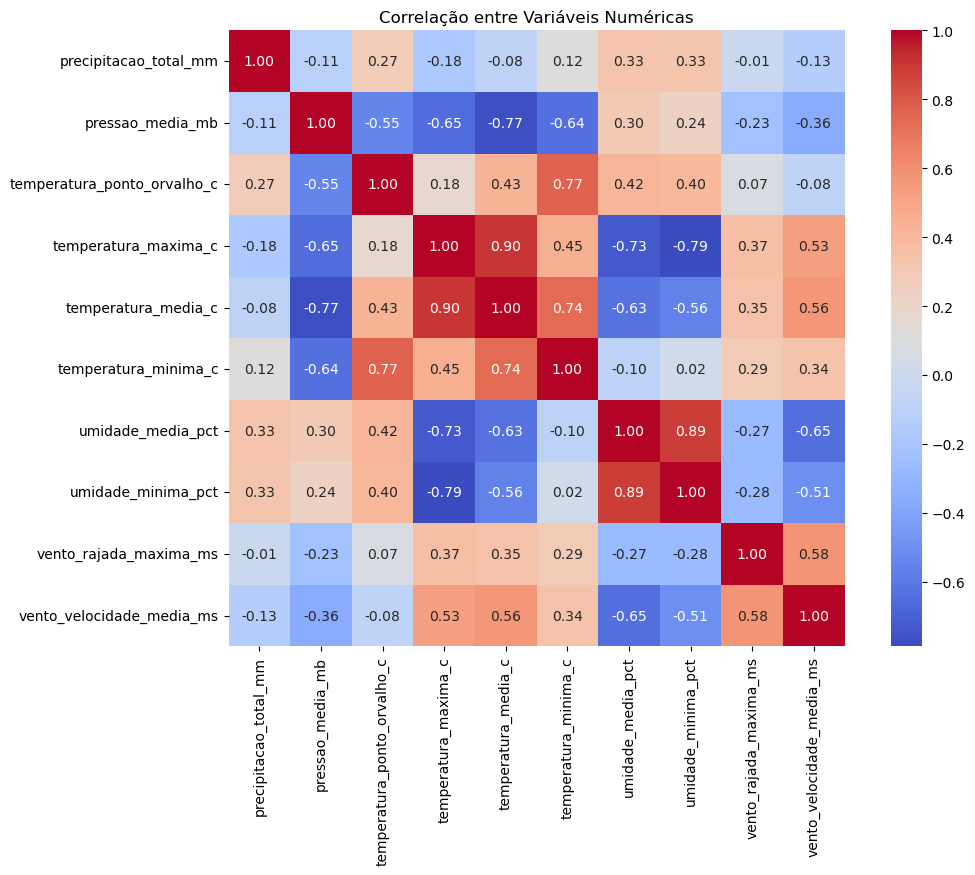

In [69]:
# Mapa de calor de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(df_eda.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlação entre Variáveis Numéricas")
plt.show()

**Interpretação:**

### 2.4 Line Chart

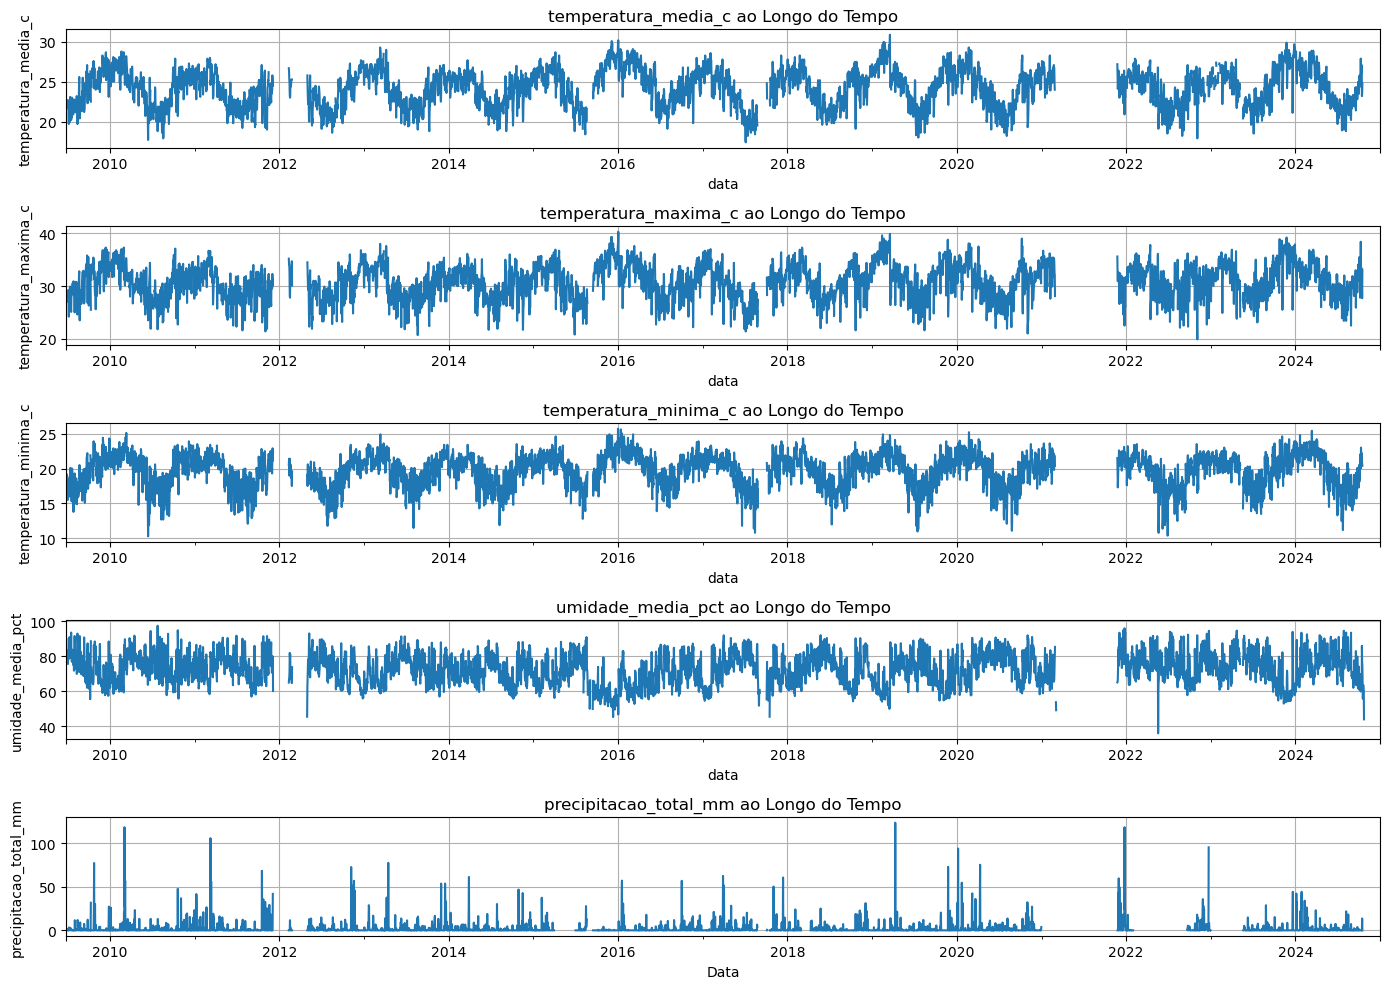

In [ ]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(variables_of_interest, 1):
    plt.subplot(len(variables_of_interest), 1, i)
    df_eda[col].plot()
    plt.title(f"{col} ao Longo do Tempo")
    plt.ylabel(col)
    plt.grid(True)

plt.xlabel("Data")
plt.tight_layout()
plt.show()

**Intepretação:**

### 2.5 Column Chart

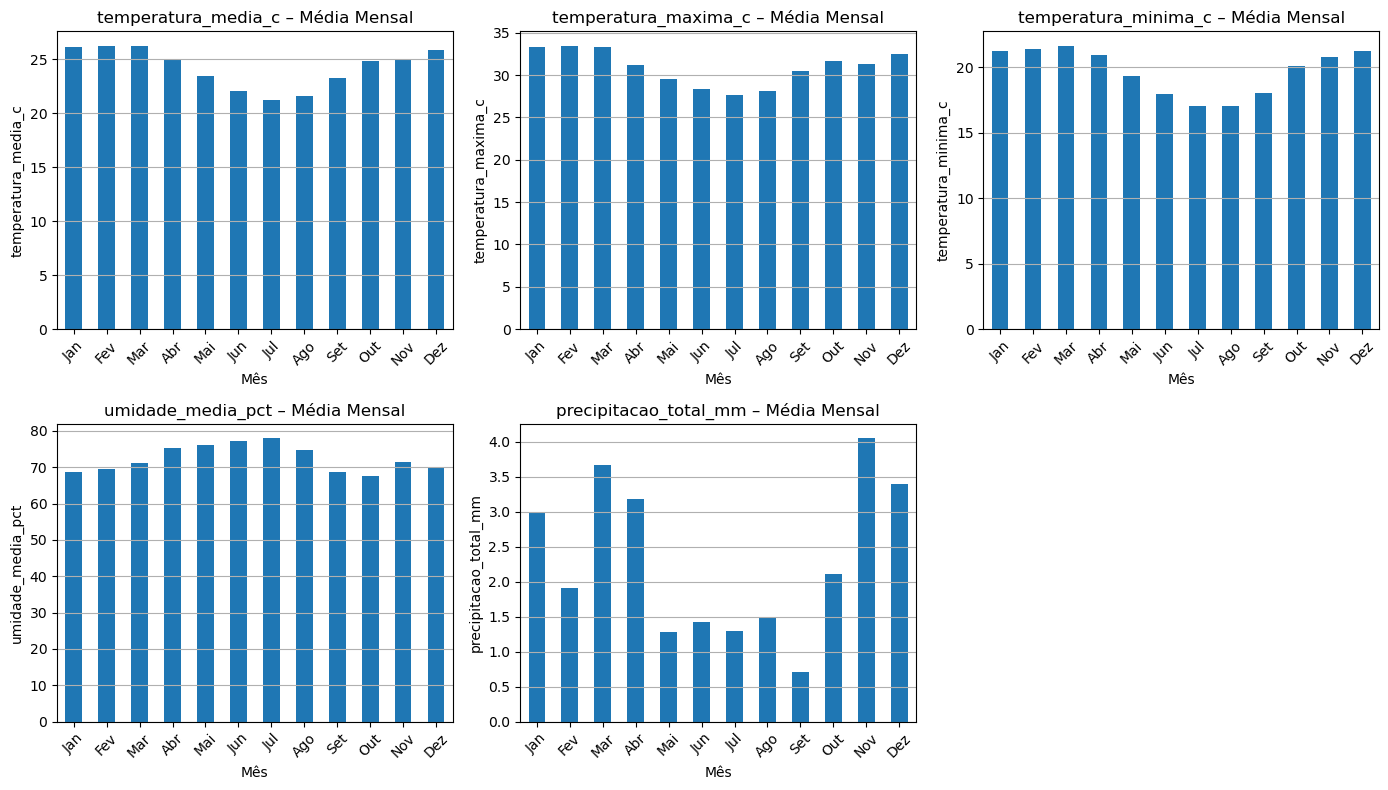

In [71]:
df_eda['Mes'] = df_eda.index.month

plt.figure(figsize=(14, 8))

for i, col in enumerate(variables_of_interest, 1):
    media_mensal = df_eda.groupby('Mes')[col].mean()

    plt.subplot(2, 3, i)
    media_mensal.plot(kind='bar')
    plt.title(f"{col} – Média Mensal")
    plt.xlabel("Mês")
    plt.ylabel(col)
    plt.xticks(
        range(0, 12),
        ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'],
        rotation=45
    )
    plt.grid(axis='y')

plt.tight_layout()
plt.show()


**Interpretação:** 

## 3. Preparation

In [72]:
def preprocess_with_all_imputations(data):
    data = data.copy()
    data.index = pd.to_datetime(data.index)

    # 1. Criação de features temporais (tensorflow documentação)
    data['Ano'] = data.index.year
    data['Mes'] = data.index.month
    data['Dia'] = data.index.day
    data['DiaSemana'] = data.index.dayofweek
    data['DiaAno'] = data.index.dayofyear

    print("Valores ausentes por coluna:\n", data.isnull().sum())

    imputations = {}

    # -------------------------------------------------------------------
    # 2. IMPUTAÇÕES BÁSICAS
    # -------------------------------------------------------------------

    ## 2.1 Forward fill
    imputations["ffill"] = data.fillna(method='ffill')

    ## 2.2 Rolling mean
    data_rolling = data.copy()
    for col in data.columns:
        if data[col].isnull().sum() > 0:
            data_rolling[col] = data[col].fillna(
                data[col].rolling(window=15, min_periods=1).mean()
            )
    imputations["rolling_mean"] = data_rolling

    ## 2.3 Geometric interpolation
    def geometric_interpolate(series):
        series = series.apply(lambda x: max(x, 1e-6) if pd.notnull(x) else np.nan)
        series = series.fillna(series.median())

        return np.exp(np.log(series).interpolate(method='linear'))

    data_geom = data.copy()
    for col in data.columns:
        if data[col].isnull().sum() > 0:
            data_geom[col] = geometric_interpolate(data[col])
    imputations["geometric"] = data_geom

    # -------------------------------------------------------------------
    # 3. IMPUTAÇÃO COM ARIMA
    # -------------------------------------------------------------------
    def arima_impute(series):
        series_filled = series.copy()

        # preenche temporariamente para rodar o ARIMA sem quebrar (talvez melhorar isso depois)
        temp = series.fillna(method="ffill").fillna(method="bfill")

        model = ARIMA(temp, order=(3, 1, 2))
        fitted = model.fit()

        pred = fitted.predict()

        # substitui apenas onde há NA
        series_filled[series.isnull()] = pred[series.isnull()]
        return series_filled

    data_arima = data.copy()
    for col in data.columns:
        if data[col].isnull().sum() > 0:
            data_arima[col] = arima_impute(data[col])
    imputations["arima"] = data_arima

    # -------------------------------------------------------------------
    # 4. IMPUTAÇÃO KNN
    # -------------------------------------------------------------------
    knn = KNNImputer(n_neighbors=5)
    data_knn = pd.DataFrame(
        knn.fit_transform(data),
        index=data.index,
        columns=data.columns
    )
    imputations["knn"] = data_knn

    # -------------------------------------------------------------------
    # 5. IMPUTAÇÃO PROPHET
    # -------------------------------------------------------------------
    def prophet_impute(series):
        df = pd.DataFrame({"ds": series.index, "y": series.values})

        # substituir NA por interpolação temporária linear
        df['y'] = df['y'].interpolate()

        model = Prophet()
        model.fit(df)

        future = model.make_future_dataframe(periods=0)
        forecast = model.predict(future)

        yhat = forecast['yhat'].values
        series_filled = series.copy()
        series_filled[series.isnull()] = yhat[series.isnull()]

        return series_filled

    data_prophet = data.copy()
    for col in data.columns:
        if data[col].isnull().sum() > 0:
            data_prophet[col] = prophet_impute(data[col])
    imputations["prophet"] = data_prophet

    # -------------------------------------------------------------------
    # 6. LEST (Locally Estimated Seasonal Trend)
    #     — usando STL decomposition
    # -------------------------------------------------------------------
    def lest_impute(series):
        series_tmp = series.fillna(method="ffill").fillna(method="bfill")

        stl = STL(series_tmp, period=365)
        result = stl.fit()

        trend = result.trend
        season = result.seasonal

        # Reconstrução
        reconstructed = trend + season

        filled = series.copy()
        filled[series.isnull()] = reconstructed[series.isnull()]

        return filled

    data_lest = data.copy()
    for col in data.columns:
        if data[col].isnull().sum() > 0:
            data_lest[col] = lest_impute(data[col])
    imputations["lest"] = data_lest
    return imputations

In [73]:
datasets = preprocess_with_all_imputations(data)

df_ffill    = datasets["ffill"]
df_roll     = datasets["rolling_mean"]
df_geom     = datasets["geometric"]
df_arima    = datasets["arima"]
df_knn      = datasets["knn"]
df_prophet  = datasets["prophet"]
df_lest     = datasets["lest"]

Valores ausentes por coluna:
 precipitacao_total_mm          1138
pressao_media_mb                571
temperatura_ponto_orvalho_c     594
temperatura_maxima_c            561
temperatura_media_c             612
temperatura_minima_c            560
umidade_media_pct               532
umidade_minima_pct              376
vento_rajada_maxima_ms          466
vento_velocidade_media_ms       662
Ano                               0
Mes                               0
Dia                               0
DiaSemana                         0
DiaAno                            0
dtype: int64


/tmp/ipykernel_69325/4235888446.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imputations["ffill"] = data.fillna(method='ffill')
/tmp/ipykernel_69325/4235888446.py:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = series.fillna(method="ffill").fillna(method="bfill")
/home/lucas/anaconda3/envs/imputacao/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/lucas/anaconda3/envs/imputacao/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/lucas/anaconda3/envs/imputacao/lib/python3.10/site-packages/statsmodels/tsa/

## 4. Train

In [20]:
def train_and_evaluate(df, n_passos=90):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df['Ano'] = df.index.year
    df['Mes'] = df.index.month
    df['Dia'] = df.index.day
    df['DiaSemana'] = df.index.dayofweek
    df['DiaAno'] = df.index.dayofyear

    target_col = 'TempMedia (AUT)(°C)'
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    if target_col not in numeric_cols:
        raise ValueError(f"Coluna alvo '{target_col}' não encontrada.")
    numeric_cols.remove(target_col)

    df['Mes_sin'] = np.sin(2 * np.pi * df['Mes'] / 12)
    df['Mes_cos'] = np.cos(2 * np.pi * df['Mes'] / 12)
    df['DiaSemana_sin'] = np.sin(2 * np.pi * df['DiaSemana'] / 7)
    df['DiaSemana_cos'] = np.cos(2 * np.pi * df['DiaSemana'] / 7)
    df['DiaAno_sin'] = np.sin(2 * np.pi * df['DiaAno'] / 365)
    df['DiaAno_cos'] = np.cos(2 * np.pi * df['DiaAno'] / 365)

    all_features = numeric_cols + ['Mes_sin', 'Mes_cos', 'DiaSemana_sin', 'DiaSemana_cos', 'DiaAno_sin', 'DiaAno_cos']

    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    df[all_features] = scaler_x.fit_transform(df[all_features])
    df[[target_col]] = scaler_y.fit_transform(df[[target_col]])

    X, y = [], []
    for i in range(n_passos, len(df)):
        X.append(df[all_features].iloc[i - n_passos:i].values.flatten())
        y.append(df[target_col].iloc[i])
    X, y = np.array(X), np.array(y)

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(1, activation='linear', kernel_regularizer=l2(0.001)))

    #learning rate tá um pouco alto, mas quando coloco o valor padrão recomendado não fica legal
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-8, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

    y_pred = model.predict(X_test).flatten()
    y_test = y_test.flatten()

    metrics = {
      'MSE': mean_squared_error(y_test, y_pred),
      'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
      'MAE': mean_absolute_error(y_test, y_pred),
      'R²': r2_score(y_test, y_pred),
      'MAPE': mape(y_test, y_pred),
      'SMAPE': smape(y_test, y_pred),
      'MPE': mpe(y_test, y_pred),
      'MASE': mase(y_test, y_pred, y_train),
    }
    model.summary()
    return model, scaler_x, scaler_y, all_features, df, metrics

## 5. Assessment

In [21]:
# Treinando os modelos com os três métodos de imputação
result_ffill   = train_and_evaluate(df_ffill)
result_rolling = train_and_evaluate(df_roll)
result_geom    = train_and_evaluate(df_geom)
result_arima   = train_and_evaluate(df_arima)
result_knn     = train_and_evaluate(df_knn)
result_prophet = train_and_evaluate(df_prophet)
result_lest    = train_and_evaluate(df_lest)


# Criar tabela de comparação
resultados = pd.DataFrame({
    'Forward Fill':             result_ffill[-1],
    'Rolling Mean':            result_rolling[-1],
    'Interpolação Geométrica': result_geom[-1],
    'ARIMA':                   result_arima[-1],
    'KNN':                     result_knn[-1],
    'Prophet':                 result_prophet[-1],
    'LEST/STL':                result_lest[-1]

}).T

print("Comparação dos métodos de imputação:\n")
print(resultados)

/home/lucas/anaconda3/envs/imputacao/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       115,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,669 (1.35 MB)

...

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,780 (921.02 KB)

/home/lucas/anaconda3/envs/imputacao/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


ValueError: Input contains NaN.